In [ ]:
# pip install -U scikit-learn
# pip install matplotlib
# pip install Pillow
# pip install seaborn
# pip install opencv-python
# pip install mtcnn
# pip install glob2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow import keras
from keras.models import load_model
from sklearn.model_selection import train_test_split
from keras.layers import  Dense, Flatten, Conv2D, Rescaling, BatchNormalization, MaxPooling2D, Dropout
import matplotlib.pyplot as plt
import os
import pickle
from glob import glob
from tqdm import tqdm
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import random
import cv2
import glob2
from mtcnn.mtcnn import MTCNN
detector = MTCNN()

In [ ]:
FOLDER_IMAGES = './datasets/binary_labels_lite'
IMG_SIZE = (64, 64)
INPUT_SHAPE =  IMG_SIZE + (3,)
BATCH_SIZE = 2
VAL_SPLIT = 0.2
MODEL_SAVE_FOLDER = './models/cnn/cnn_simple/'
EPOCHS = 30

In [76]:
file_paths = glob2.glob(FOLDER_IMAGES + '/**/*.jpg')

def plot_images(images):
    # Create a new figure
    plt.figure(figsize=(10,10))

    for i, img in enumerate(images):
        # Subplot for each image
        plt.subplot(1, len(images), i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.show()

def crop_img(img, box):
    x, y, width, height = box
    return img.crop((x, y, x + width, y + height))

def preprocess_image(file_path):
    img = Image.open(file_path)
    img.thumbnail((500,500))

    faces = detector.detect_faces(np.array(img))
    box = faces[0]['box']
    img = crop_img(img, box)

    # https://pillow.readthedocs.io/en/stable/handbook/concepts.html#modes
    img = img.convert("RGB")
    img = img.resize(IMG_SIZE)

    tensor_img = tf.convert_to_tensor(np.array(img))
    # tensor_img = tensor_img / 255

    label = tf.constant('awake' if 'awake' in file_path else 'drowsy')
    # plt.imshow(img)
    # plt.show()
    print(label, img.size, img.mode)

    return tensor_img, label

# First, preprocess all image files to get a list of (image, label) tuples
image_data = [preprocess_image(file_path)[0] for file_path in file_paths]
label_data = [preprocess_image(file_path)[1] for file_path in file_paths]

# Convert the list into a TensorFlow dataset
image_ds = tf.data.Dataset.from_tensor_slices(image_data)
label_ds = tf.data.Dataset.from_tensor_slices(label_data)

train_ds = tf.data.Dataset.zip((image_ds, label_ds)).batch(BATCH_SIZE)

tf.Tensor(b'awake', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'awake', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'awake', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'awake', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'drowsy', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'drowsy', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'drowsy', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'drowsy', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'awake', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'awake', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'awake', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'awake', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'drowsy', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'drowsy', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'drowsy', shape=(), dtype=string) (64, 64) RGB
tf.Tensor(b'drowsy', shape=(), dtype=string) (64, 64) RGB


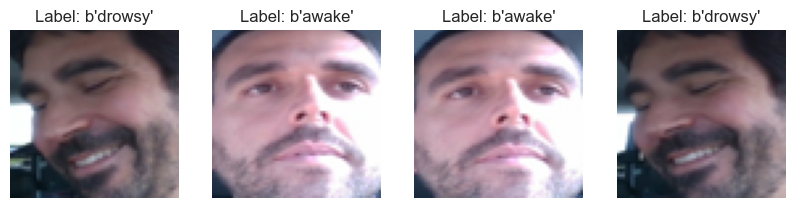

In [79]:
def plot_images_from_dataset(dataset, num_images):

    dataset = dataset.shuffle(1000)

    # Create a new figure
    plt.figure(figsize=(10,10))

    # Take the first 5 elements from the dataset
    for i, (img_batch, label_batch) in enumerate(dataset.take(num_images)):
        # Subplot for each image
        plt.subplot(1, num_images, i+1)
        # Extract the first image from the batch
        img = img_batch[0]
        label = label_batch[0]
        plt.imshow(img.numpy())
        plt.title(f'Label: {label.numpy()}')
        plt.axis('off')

    plt.show()

plot_images_from_dataset(train_ds,4)